In [152]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 
from sklearn.model_selection import train_test_split 
from sklearn.linear_model import LinearRegression 
from sklearn.metrics import mean_squared_error, r2_score 
from sklearn.preprocessing import StandardScaler 
import warnings 
warnings.filterwarnings('ignore')

In [153]:
data = pd.read_csv(r"C:\Users\ASUS\Downloads\Boston housing dataset.csv")

In [154]:
data.head() 

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,NaN,36.2


In [155]:
data.shape 

(506, 14)

In [156]:
data.info() 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     486 non-null    float64
 1   ZN       486 non-null    float64
 2   INDUS    486 non-null    float64
 3   CHAS     486 non-null    float64
 4   NOX      506 non-null    float64
 5   RM       506 non-null    float64
 6   AGE      486 non-null    float64
 7   DIS      506 non-null    float64
 8   RAD      506 non-null    int64  
 9   TAX      506 non-null    int64  
 10  PTRATIO  506 non-null    float64
 11  B        506 non-null    float64
 12  LSTAT    486 non-null    float64
 13  MEDV     506 non-null    float64
dtypes: float64(12), int64(2)
memory usage: 55.5 KB


In [157]:
data.nunique() 

CRIM       484
ZN          26
INDUS       76
CHAS         2
NOX         81
RM         446
AGE        348
DIS        412
RAD          9
TAX         66
PTRATIO     46
B          357
LSTAT      438
MEDV       229
dtype: int64

In [158]:
data.CHAS.unique() 

array([ 0., nan,  1.])

In [159]:
data.ZN.unique() 

array([ 18. ,   0. ,  12.5,  75. ,  21. ,  90. ,  85. , 100. ,  25. ,
        17.5,  80. ,   nan,  28. ,  45. ,  60. ,  95. ,  82.5,  30. ,
        22. ,  20. ,  40. ,  55. ,  52.5,  70. ,  34. ,  33. ,  35. ])

In [160]:
data.isnull().sum() 

CRIM       20
ZN         20
INDUS      20
CHAS       20
NOX         0
RM          0
AGE        20
DIS         0
RAD         0
TAX         0
PTRATIO     0
B           0
LSTAT      20
MEDV        0
dtype: int64

In [161]:
data.duplicated().sum() 

0

In [162]:
df = data.copy() 

In [163]:
df.isnull().sum()

CRIM       20
ZN         20
INDUS      20
CHAS       20
NOX         0
RM          0
AGE        20
DIS         0
RAD         0
TAX         0
PTRATIO     0
B           0
LSTAT      20
MEDV        0
dtype: int64

In [164]:
df.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,NaN,36.2


In [165]:
df['CHAS'] = df['CHAS'].fillna(0).astype(int)

In [166]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
CRIM,486.0,3.611874,8.720192,0.00632,0.081900,0.253715,3.560263,88.9762
ZN,486.0,11.211934,23.388876,0.00000,0.000000,0.000000,12.500000,100.0000
INDUS,486.0,11.083992,6.835896,0.46000,5.190000,9.690000,18.100000,27.7400
CHAS,506.0,0.067194,0.250605,0.00000,0.000000,0.000000,0.000000,1.0000
NOX,506.0,0.554695,0.115878,0.38500,0.449000,0.538000,0.624000,0.8710
RM,506.0,6.284634,0.702617,3.56100,5.885500,6.208500,6.623500,8.7800
AGE,486.0,68.518519,27.999513,2.90000,45.175000,76.800000,93.975000,100.0000
DIS,506.0,3.795043,2.105710,1.12960,2.100175,3.207450,5.188425,12.1265
RAD,506.0,9.549407,8.707259,1.00000,4.000000,5.000000,24.000000,24.0000
TAX,506.0,408.237154,168.537116,187.00000,279.000000,330.000000,666.000000,711.0000


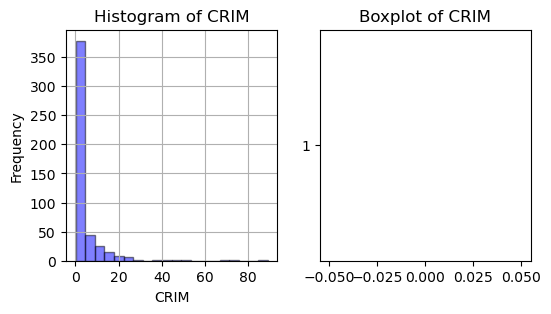

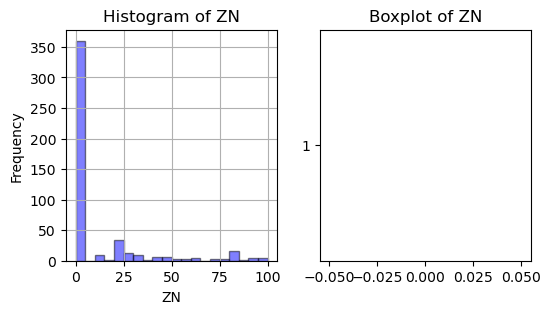

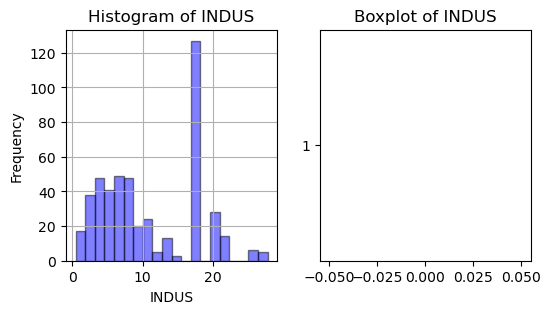

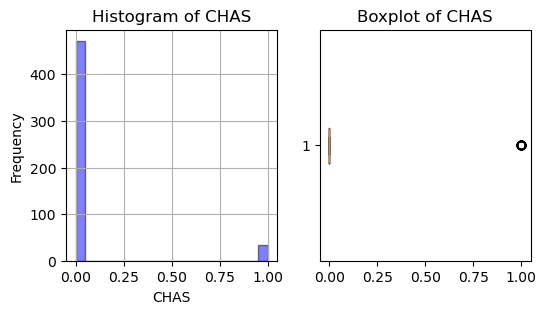

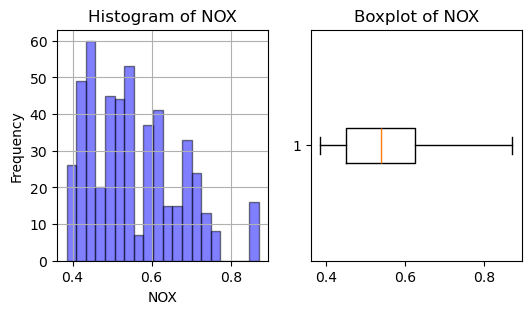

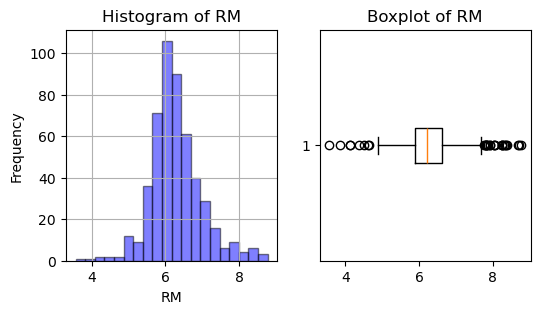

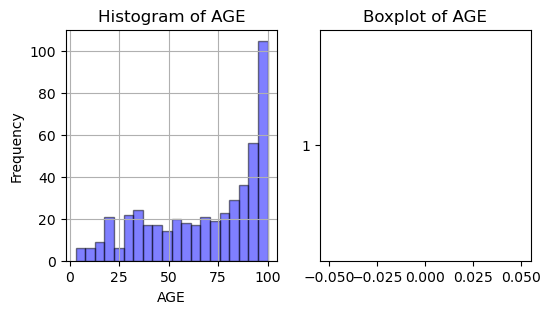

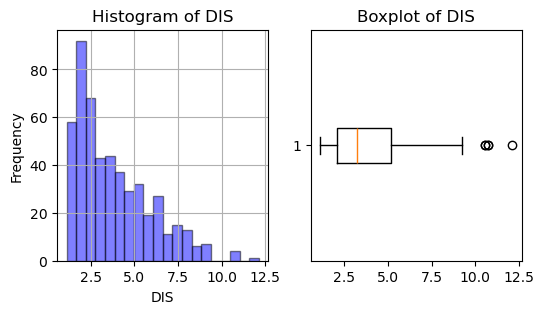

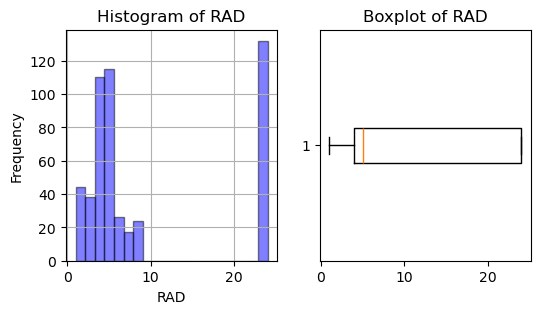

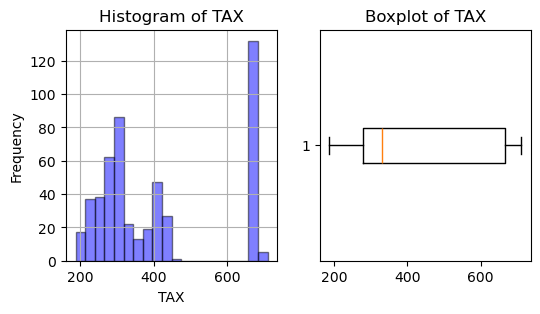

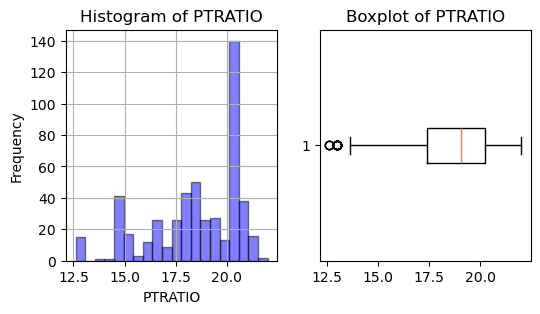

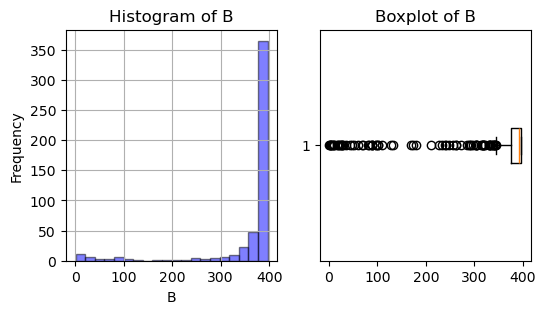

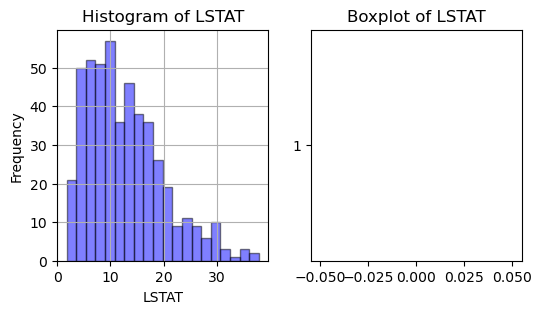

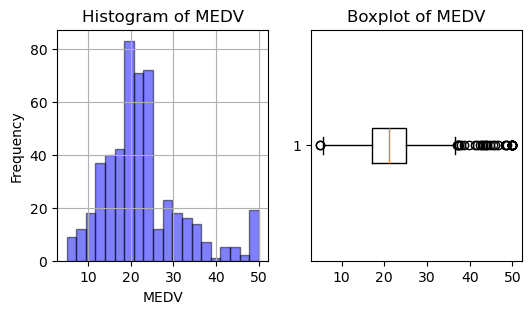

In [167]:
for i in df.columns: 
    plt.figure(figsize=(6,3)) 
    plt.subplot(1, 2, 1) 
    df[i].hist(bins=20, alpha=0.5, color='b',edgecolor='black') 
    plt.title(f'Histogram of {i}') 
    plt.xlabel(i) 
    plt.ylabel('Frequency') 
    plt.subplot(1, 2, 2) 
    plt.boxplot(df[i], vert=False) 
    plt.title(f'Boxplot of {i}')
    plt.show() 

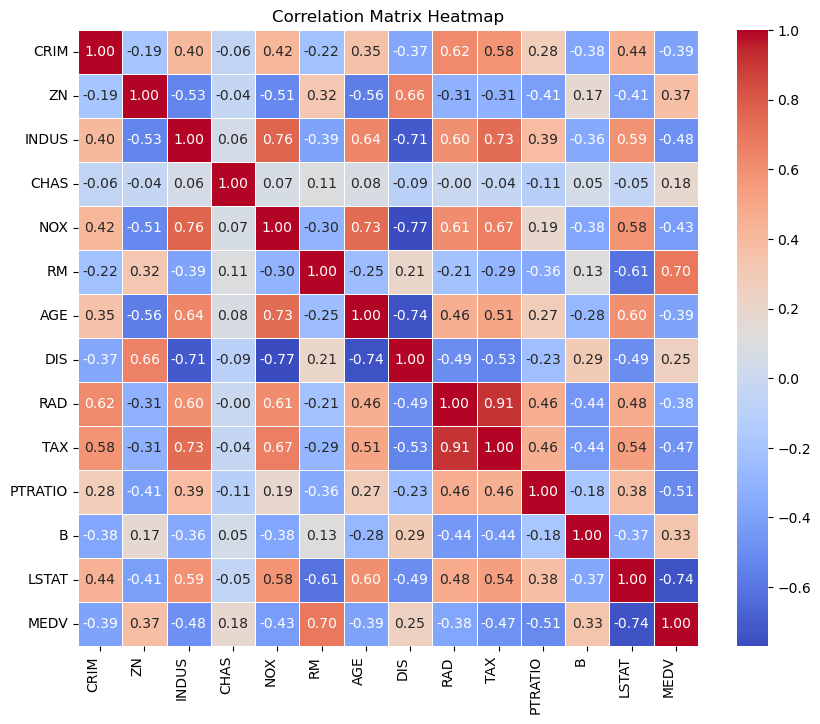

In [168]:
corr = df.corr(method='pearson') 
plt.figure(figsize=(10, 8)) 
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5) 
plt.xticks(rotation=90, ha='right') 
plt.yticks(rotation=0) 
plt.title("Correlation Matrix Heatmap") 
plt.show() 

In [169]:
X = df.drop('MEDV', axis=1)  
y = df['MEDV'] 

In [170]:
scale = StandardScaler() 
X_scaled = scale.fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(X_scaled , y, test_size=0.2, random_state=42)

In [171]:

from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy='mean')
X_train_imputed = imputer.fit_transform(X_train)
X_test_imputed = imputer.transform(X_test)

model = LinearRegression()

model.fit(X_train_imputed, y_train)

LinearRegression()

In [172]:
y_pred = model.predict(X_test_imputed)

y_pred

array([29.15319492, 36.59039882, 14.49549652, 25.09379366, 18.45421467,
       23.01575367, 18.13526669, 14.60502663, 22.12831929, 20.86582485,
       25.12948072, 18.52546231, -5.66700432, 21.73419842, 19.05393864,
       25.52935473, 19.65719506,  5.89696236, 40.98116154, 17.23363067,
       24.98486382, 30.293067  , 11.78980489, 23.05177286, 17.35222358,
       15.12129902, 21.20172439, 14.49387168, 23.15307394, 19.43601285,
       22.54785006, 25.2385533 , 25.92527476, 16.65149996, 16.45432113,
       16.62094025, 31.10757605, 20.28673067, 24.41154838, 22.73529437,
       14.52054528, 32.35793639, 43.02198539, 17.64993812, 27.62882215,
       16.43761567, 14.24340474, 26.16895764, 19.77375441, 30.14860173,
       20.97847441, 33.8398481 , 16.40203875, 26.38859524, 39.78859381,
       22.06906776, 18.4071925 , 32.82541889, 25.41056788, 12.79710983,
       22.7852221 , 30.74765064, 31.42069065, 16.32223949, 20.35282031,
       17.20605903, 20.17561873, 26.19068244, 30.94948045, 11.39

In [173]:
mse = mean_squared_error(y_test, y_pred)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, y_pred)

print(f'Mean Squared Error: {mse}')
print(f'Root Mean Squared Error: {rmse}')
print(f'R-squared: {r2}')

Mean Squared Error: 25.030233165054796
Root Mean Squared Error: 5.003022403013482
R-squared: 0.6586807323122348
